## 라이브러리

In [96]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier as lgb
import xgboost as xgb

from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier


# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 3.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 데이터 불러오기

In [185]:
df = pd.read_csv("컬럼중요도30개 선택.csv")

In [198]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('ID')
cat_cols

['Segment', '이용금액대']

In [199]:
df.columns

Index(['ID', 'Segment', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크'],
      dtype='object')

In [ ]:
df = df.drop('ID.1', axis = 1)

In [201]:
df2 = df.copy()

In [202]:
# Segment 인코딩 사전
le_seg = LabelEncoder()
df2['Segment'] = le_seg.fit_transform(df2['Segment'])
seg_map = {cls: idx for idx, cls in enumerate(le_seg.classes_)}
print("Segment 인코딩 매핑 →", seg_map)

Segment 인코딩 매핑 → {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}


In [203]:
# 문자열 -> 숫자
encoder_dict = {}
for col in cat_cols:  # cat_cols = ['방문횟수_PC_R6M', ...]
    le_col = LabelEncoder()
    df2[col] = le_col.fit_transform(df2[col])
    encoder_dict[col] = le_col  # 저장해둠

In [204]:
df3 = df2.copy()

In [205]:
# 입력과 결과로 나눈다
X = df3.drop(['ID','Segment'], axis = 1)
y = df3['Segment']

In [206]:
# 스케일링

# 0) 원본 보존
X_scaled_all = X.copy()

# 1) 숫자형만 선택
num_cols = X.select_dtypes(include='number').columns

# 2) 스케일링
scaler = StandardScaler()
X_scaled_vals = scaler.fit_transform(X[num_cols])

# 3) 원본 DataFrame에 **덮어쓰기**
X_scaled_all[num_cols] = X_scaled_vals

# 🔹 이제 X_scaled_all 은 숫자형(표준화) + 범주형 그대로 포함



In [207]:
train_X = X_scaled_all
train_y = y

In [208]:
# 1️⃣ 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    train_X, train_y, test_size=0.2, stratify=y, random_state=42)

## 예측 모델

```

[Step 0]  입력 데이터  (X_train, y_train, X_test, y_test)
           │
           ▼
[Step 1]  🎯 Gate 모델  = lgb_bin  (LightGBM, A/B vs C·D·E)
           │   ├─ 훈련 : y_train_bin  (A·B→1, C·D·E→0)
           │   ├─ 예측 : val_proba = lgb_bin.predict_proba(X_test)[:,1]
           │   └─ 임계치 : thr_ab  (Brent 알고리즘으로 F1이 최대치가 되도록)
           │
           ├─── val_proba ≥ thr_ab   →  ✅ A·B 후보
           │         │
           │         ▼
           │   [Step 2-A]  cat_ab  (CatBoost, A vs B 세부 분류)
           │         └─ 산출 : 최종 라벨 A or B
           │
           └─── val_proba < thr_ab  →  ✅ C·D·E 후보
                     │
                     ▼
               [Step 2-B]  xgb_cde  (XGBoost, C vs D vs E 다중 분류)
                     └─ 산출 : 최종 라벨 C, D, 또는 E


* 학습 때 사용한 Gate 모델 (분기한 기준)을 평가와 예측 때도 사용하여 A,B / C,D,E  나눈 기준을 일관성 있게 유지
```

전문가 시스템
1) C,D만 뽑아서 이진분류 하고 잘 되는지 먼저 확인
2) C,D / E 이진 분류 해서 확인

### Gate 모델 (A,B / C,D,E 분기)

In [209]:
# 2. 게이트 모델 (A/B vs CDE)
# ---------------------------------------------------------------
from lightgbm import LGBMClassifier, early_stopping
from scipy.optimize import brent
from sklearn.metrics import f1_score

# 1) 타깃 레이블 (A, B)
# --------------------------------------------------------------
ab_codes   = [seg_map['A'], seg_map['B']]
y_train_bin = y_train.isin(ab_codes).astype(int)
y_test_bin  = y_test.isin(ab_codes).astype(int)


# 2) LightGBM 하이퍼파라미터 설정
#    - GPU 사용 (device_type='gpu')
#    - class_weight='balanced' : 불균형 자동 보정
# --------------------------------------------------------------
lgb_bin = LGBMClassifier(
    #device_type='gpu',
    class_weight='balanced',
    num_leaves=63, learning_rate=0.05, n_estimators=600,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)

# 3) 모델 학습
#    - 검증셋: (X_test, y_test_bin)
#    - early_stopping 콜백: 50회 연속 개선 없으면 중단
# --------------------------------------------------------------
lgb_bin.fit(
    X_train, y_train_bin,
    eval_set=[(X_test, y_test_bin)],
    eval_metric='binary_logloss',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
)

# 4) 검증 데이터의 “A/B일 확률” 추출
#    predict_proba() → (N, 2) 행렬
#    [:, 1]          → positive 클래스(=A/B) 확률만 슬라이스
# --------------------------------------------------------------
val_proba = lgb_bin.predict_proba(X_test)[:, 1]


# 5) F1-score를 최대화하는 확률 임계치(threshold) 찾기
#    - Brent 알고리즘: 0.1~0.9 구간에서 1차원 최적화
# --------------------------------------------------------------
def best_thr(p, y_true):
    return brent(lambda t: -f1_score(y_true, (p >= t).astype(int)),
                 brack=(0.1, 0.9))

thr_ab = best_thr(val_proba, y_test_bin)
print(f"🔑  Gate threshold = {thr_ab:.3f}")


# 6) 최적 threshold로 “A/B 후보” 마스크 생성
#    - mask_ab == True  → Gate가 A/B라고 본 샘플
#    - mask_ab == False → Gate가 C/D/E라고 본 샘플
# --------------------------------------------------------------
mask_ab = val_proba >= thr_ab


[LightGBM] [Info] Number of positive: 893, number of negative: 1919107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7146
[LightGBM] [Info] Number of data points in the train set: 1920000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
🔑  Gate threshold = 0.736


In [ ]:
# import matplotlib.pyplot as plt
# import lightgbm as lgb

# # 0번째 트리 시각화 (큰 영향을 주는 초기 트리부터)
# lgb.plot_tree(lgb_bin, tree_index=0, figsize=(50,40),
#               show_info=["split_gain", "threshold", "value"])
# plt.show()


In [211]:
# ===============================================================
# 3. A/B 세부 분류 (CatBoost)
# ===============================================================
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from catboost import CatBoostClassifier

# (3-1) A/B 행만 추출
sel_ab_tr = y_train.isin(ab_codes)
X_ab_tr, y_ab_tr = X_train[sel_ab_tr], y_train[sel_ab_tr]

# (3-2) 범주형 위치 인덱스
# cat_cols  = ['이용금액대']
# cate_idx  = [X_ab_tr.columns.get_loc(c) for c in cat_cols]

# (3-3) SMOTE-NC 증식
smote_ab  = SMOTENC(categorical_features=cate_idx, random_state=42)
X_ab_res, y_ab_res = smote_ab.fit_resample(X_ab_tr, y_ab_tr)

# (3-4) 내부 검증 셋 분할  (A/B만 포함)
X_ab_train, X_ab_valid, y_ab_train, y_ab_valid = train_test_split(
    X_ab_res, y_ab_res,
    test_size=0.15, stratify=y_ab_res, random_state=42
)

# (3-5) CatBoost 학습
cat_ab = CatBoostClassifier(
    #task_type='GPU', devices='0',
    iterations=800, depth=7, learning_rate=0.08,
    bagging_temperature=1, auto_class_weights='Balanced',
    random_state=42, early_stopping_rounds=50, verbose=False
)

cat_ab.fit(
    X_ab_train, y_ab_train,
    eval_set=(X_ab_valid, y_ab_valid)   # ← A/B만 있는 안전한 검증 셋
)

# 이제 cat_ab는 정상적으로 학습 완료!


In [231]:
import pandas as pd
from sklearn.metrics import classification_report

# 1️⃣ cat_ab 로 전체 X_test 예측
prob_AB = cat_ab.predict_proba(X_test)          # (N,2)   0=A , 1=B
pred_AB = prob_AB.argmax(1)                     # 0/1
pred_lab = pd.Series(pred_AB, index=X_test.index).map({0:'A', 1:'B'})

# 2️⃣ 실제 라벨(문자, A~E)
true_lab = y_test.map({v:k for k,v in seg_map.items()})

# 3️⃣ “실제 A·B” 행만 성능 지표
mask_ab = true_lab.isin(['A','B'])
print("📑 classification_report (실제 A·B 행만)")
print(classification_report(
    true_lab[mask_ab], pred_lab[mask_ab],
    labels=['A','B']
))

# 4️⃣ 전체 A~E × 예측(A,B) 비율표
cross_tab = (
    pd.crosstab(true_lab, pred_lab, normalize='index')
      .reindex(index=['A','B','C','D','E'], columns=['A','B'])
      .fillna(0)
)

print("\n🔍 전체 A~E → 예측(A,B) 비율")
display(cross_tab.style.format('{:.2%}'))


📑 classification_report (실제 A·B 행만)
              precision    recall  f1-score   support

           A       0.99      0.98      0.99       194
           B       0.88      0.97      0.92        29

    accuracy                           0.98       223
   macro avg       0.93      0.97      0.95       223
weighted avg       0.98      0.98      0.98       223


🔍 전체 A~E → 예측(A,B) 비율


col_0,A,B
Segment,,
A,97.94%,2.06%
B,3.45%,96.55%
C,46.80%,53.20%
D,40.62%,59.38%
E,60.57%,39.43%


In [213]:
# ===============================================================
# 4. C/D/E 분류 (XGBoost)
# ===============================================================
cde_codes = [seg_map[c] for c in ['C', 'D', 'E']]

# --- (4-1) 학습용(Train) ---------------------------
sel_cde_tr = y_train.isin(cde_codes)          # ← 정답 기준 C/D/E 행
le_cde     = LabelEncoder()
y_cde_enc  = le_cde.fit_transform(y_train[sel_cde_tr])

# --- (4-2) 검증용(Valid) --------------------------
# 게이트 예측(~mask_ab) ∩ 정답도 C/D/E → "진짜 C/D/E"
# (필터링한 검증 마스크는 그대로 사용)
cde_mask_test = (~mask_ab) & y_test.isin(cde_codes)

xgb_cde = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    #tree_method='gpu_hist', predictor='gpu_predictor',
    max_depth=9, min_child_weight=3, gamma=0.3,
    subsample=0.8, colsample_bytree=0.8,
    eta=0.06, reg_lambda=3, reg_alpha=1,
    n_estimators=800,                # ← 조기 종료 못 쓰니 적당히 늘리거나 줄여서
    random_state=42, verbosity=0
)

xgb_cde.fit(
    X_train[sel_cde_tr], y_cde_enc,
    eval_set=[(
        X_test[cde_mask_test],
        le_cde.transform(y_test[cde_mask_test])
    )],
    verbose=False            # ← 버그 없는 파라미터
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.06, eval_metric=None,
              feature_types=None, feature_weights=None, gamma=0.3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None, ...)

Segment
True     479746
False       254
Name: count, dtype: int64

### C,D만 뽑아서 학습하고 잘 예측하는지 확인해보자

In [214]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# ──────────────────────────────────────────────
# 1) C·D 학습 데이터 추출
# ──────────────────────────────────────────────
cd_codes = [seg_map['C'], seg_map['D']]

tr_mask = y_train.isin(cd_codes)
X_tr_cd = X_train[tr_mask]
le_cd   = LabelEncoder()                    # C→0 , D→1
y_tr_cd = le_cd.fit_transform(y_train[tr_mask])

# ──────────────────────────────────────────────
# 2) C·D 이진 모델 학습 (XGBoost 예시)
# ──────────────────────────────────────────────
xgb_cd = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    max_depth=9, n_estimators=600,
    learning_rate=0.06, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_cd.fit(X_tr_cd, y_tr_cd)

# ──────────────────────────────────────────────
# 3) 전체 X_test(A~E) → C or D 예측
# ──────────────────────────────────────────────
pred_bin = xgb_cd.predict(X_test)                # 0/1
pred_lab = pd.Series(pred_bin, index=X_test.index).map({0:'C', 1:'D'})

true_lab = pd.Series(
    y_test, index=X_test.index
).map({v:k for k,v in seg_map.items()})          # 0,1,2,3,4 → A~E

# ──────────────────────────────────────────────
# 4) 실제 C·D 행만 성능
# ──────────────────────────────────────────────
mask_cd = true_lab.isin(['C','D'])
print("📑 classification_report (실제 C·D 행만)")
print(classification_report(
    true_lab[mask_cd], pred_lab[mask_cd],
    labels=['C','D']
))

# ──────────────────────────────────────────────
# 5) 전체 A~E × 예측(C,D) 비율표
# ──────────────────────────────────────────────
cross_tab = (
    pd.crosstab(true_lab, pred_lab, normalize='index')
      .reindex(index=['A','B','C','D','E'], columns=['C','D'])
      .fillna(0)
)

print("\n🔍 전체 A~E → 예측(C,D) 분포")
display(cross_tab.style.format('{:.2%}'))


📑 classification_report (실제 C·D 행만)
              precision    recall  f1-score   support

           C       0.84      0.70      0.76     25518
           D       0.90      0.95      0.92     69848

    accuracy                           0.88     95366
   macro avg       0.87      0.83      0.84     95366
weighted avg       0.88      0.88      0.88     95366


🔍 전체 A~E → 예측(C,D) 분포


col_0,C,D
Segment,,
A,99.48%,0.52%
B,100.00%,0.00%
C,70.07%,29.93%
D,4.93%,95.07%
E,1.87%,98.13%


In [232]:
import pandas as pd
import numpy as np

# 1) P(D) 확률 벡터 ― index를 y_test와 맞춘다
proba_D = pd.Series(
    xgb_cd.predict_proba(X_test)[:, 1],      # P(D)
    index=y_test.index, name='P(D)'
)

# 2) 실제 라벨(문자)
inv_seg  = {v:k for k, v in seg_map.items()}        # {2:'C', 3:'D', ...}
true_lab = y_test.map(inv_seg)                      # A~E 문자

# 3) 예측 라벨 (C or D)
pred_bin = (proba_D >= 0.5).astype(int)             # 1 = D 예측
pred_lab = pd.Series(pred_bin, index=y_test.index).map({0:'C', 1:'D'})

# 4) 마스크
mask_CtoD = (true_lab == 'C') & (pred_lab == 'D')   # ❌ C → D (오류)
mask_DtoD = (true_lab == 'D') & (pred_lab == 'D')   # ✅ D → D (정답)

# 5) 통계 요약
def stats(arr):
    return {
        'count': arr.size,
        'mean' : arr.mean(),
        'std'  : arr.std(ddof=0)
    }

stats_err = stats(proba_D[mask_CtoD].values)
stats_ok  = stats(proba_D[mask_DtoD].values)

print(f"❌ C→D  | N={stats_err['count']:,}  "
      f"μ={stats_err['mean']:.3f}  σ={stats_err['std']:.3f}")

print(f"✅ D→D  | N={stats_ok['count']:,}  "
      f"μ={stats_ok['mean']:.3f}  σ={stats_ok['std']:.3f}")


❌ C→D  | N=7,637  μ=0.723  σ=0.136
✅ D→D  | N=66,407  μ=0.907  σ=0.106


### 최적의 임계값을 찾는 알고리즘

In [163]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────
# 0) P(D) 확률 (이미 계산돼 있다면 그대로 재사용)
# ──────────────────────────────────────────────
proba_D = pd.Series(
    xgb_cd.predict_proba(X_test)[:, 1],      # P(D)
    index=y_test.index
)

# ──────────────────────────────────────────────
# 1) 밴드 컷(upper / lower) 적용
#    upper 이상  → D 확정
#    lower 이하 → C 확정
#    중간       → 기본 0.5 기준으로 판단
# ──────────────────────────────────────────────
upper, lower = 0.85, 0.63

pred_lab_thr = pd.Series(index=y_test.index, dtype=object)

# (1) 확신이 큰 영역
pred_lab_thr[proba_D >= upper] = 'D'
pred_lab_thr[proba_D <= lower] = 'C'

# (2) 중간 영역은 기본 0.5 컷
mid_mask = pred_lab_thr.isna()
pred_lab_thr[mid_mask] = np.where(
    proba_D[mid_mask] >= 0.5, 'D', 'C'
)

# 실제 라벨(문자)
true_lab = y_test.map({v:k for k,v in seg_map.items()})

# ──────────────────────────────────────────────
# 2) 실제 C·D 행만 성능
# ──────────────────────────────────────────────
mask_cd = true_lab.isin(['C','D'])
print(f"📑 threshold τ={tau} 적용 후 (실제 C·D만)")
print(classification_report(
    true_lab[mask_cd], pred_lab_thr[mask_cd],
    labels=['C','D']
))

# ──────────────────────────────────────────────
# 3) 전체 A~E × 예측(C,D) 비율표
# ──────────────────────────────────────────────
cross_tab = (
    pd.crosstab(true_lab, pred_lab_thr, normalize='index')
      .reindex(index=['A','B','C','D','E'], columns=['C','D'])
      .fillna(0)
)
print("\n🔍 전체 A~E → 예측(C,D) 분포 (τ=0.911)")
display(cross_tab.style.format('{:.2%}'))


📑 threshold τ=0.85 적용 후 (실제 C·D만)
              precision    recall  f1-score   support

           C       0.78      0.80      0.79     25518
           D       0.93      0.92      0.92     69848

    accuracy                           0.89     95366
   macro avg       0.86      0.86      0.86     95366
weighted avg       0.89      0.89      0.89     95366


🔍 전체 A~E → 예측(C,D) 분포 (τ=0.911)


col_0,C,D
Segment,,
A,99.48%,0.52%
B,100.00%,0.00%
C,80.43%,19.57%
D,8.06%,91.94%
E,3.95%,96.05%


### 분기한 컬럼 확인

In [67]:
import pandas as pd

# 중요도(기본은 split 횟수). gain·cover 등으로도 조회 가능
imp = pd.Series(lgb_bin.feature_importances_,
                index = lgb_bin.feature_name_,
                name  = "split_count").sort_values(ascending=False)

# 상위 20개 확인
top20 = imp.head(20)
print(top20)

# 필요하면 % 비율로 보고 싶다면
imp_gain = pd.Series(
    lgb_bin.booster_.feature_importance(importance_type="gain"),
    index = lgb_bin.feature_name_, name="gain"
).sort_values(ascending=False)

pd.concat([top20, imp_gain], axis=1).head(20)


입회경과개월수_신용            4733
최종이용일자_할부             2596
잔액_신판ca최대한도소진율_r6m    2173
최종이용일자_CA             2019
CL이자율_할인전             1954
최종이용일자_체크             1915
CA이자율_할인전             1799
카드이용한도금액              1752
_1순위업종_이용금액           1396
최대이용금액_일시불_R12M       1392
월중평잔                  1350
_2순위업종_이용금액           1118
최대이용금액_할부_R12M        1064
이용금액_할부_R12M          1017
이용금액_일시불_B0M           995
잔액_할부_B0M              967
쇼핑_도소매_이용금액            939
이용금액_할부_무이자_R3M        823
_2순위쇼핑업종_이용금액          812
정상청구원금_B0M             801
Name: split_count, dtype: int32


,split_count,gain
입회경과개월수_신용,4733.0,3.626650e+05
최종이용일자_할부,2596.0,1.009481e+05
잔액_신판ca최대한도소진율_r6m,2173.0,1.998917e+05
최종이용일자_CA,2019.0,5.616446e+04
CL이자율_할인전,1954.0,6.926393e+04
최종이용일자_체크,1915.0,3.723133e+04
CA이자율_할인전,1799.0,7.363249e+04
카드이용한도금액,1752.0,1.268437e+06
_1순위업종_이용금액,1396.0,6.241593e+04
최대이용금액_일시불_R12M,1392.0,5.670208e+04


In [ ]:
10/0

ZeroDivisionError: division by zero

### 평가

In [166]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────
# 1) A/B 예측 ─ cat_ab   (mask_ab == True)
# ──────────────────────────────────────────────
idx_ab = X_test.index[mask_ab]               # A/B 대상 인덱스
proba_ab = cat_ab.predict_proba(X_test.loc[idx_ab])
pred_ab  = proba_ab.argmax(1)                   # 0:A , 1:B
code_ab  = np.array([seg_map['A'], seg_map['B']])[pred_ab]

# ──────────────────────────────────────────────
# 2) C/D/E 예측 ─ xgb_cde (mask_ab == False)
# ──────────────────────────────────────────────
idx_cde  = X_test.index[~mask_ab]
proba_cde   = xgb_cde.predict_proba(X_test.loc[idx_cde])
pred_cde_e  = proba_cde.argmax(1)               # 0/1/2
code_cde    = le_cde.inverse_transform(pred_cde_e)  # 2/3/4 (C/D/E)

# ──────────────────────────────────────────────
# 3) 예측 통합  (Series, index 맞추기)
# ──────────────────────────────────────────────
y_pred = pd.Series(index=X_test.index, dtype=int)
y_pred.loc[idx_ab]  = code_ab
y_pred.loc[idx_cde] = code_cde

# NaN 체크
assert y_pred.isna().sum() == 0, "⚠️ 예측 안 된 샘플이 있습니다."

# ──────────────────────────────────────────────
# 4) 평가 지표
# ──────────────────────────────────────────────
macro_f1 = f1_score(y_test, y_pred, average="macro")
micro_f1 = f1_score(y_test, y_pred, average="micro")
print(f"🎯 Macro F1: {macro_f1:.4f}   |   Micro F1: {micro_f1:.4f}\n")

print(classification_report(
    y_test.map({v:k for k,v in seg_map.items()}),
    y_pred.map({v:k for k,v in seg_map.items()}),
    labels=['A','B','C','D','E'])
)

# ──────────────────────────────────────────────
# 5) Confusion Matrix (행=실제, 열=예측)
# ──────────────────────────────────────────────
label_order = [seg_map[c] for c in ["A","B","C","D","E"]]
cm = confusion_matrix(y_test, y_pred, labels=label_order)

cm_df = pd.DataFrame(
    cm,
    index=[f"실제 {c}" for c in "ABCDE"],
    columns=[f"예측 {c}" for c in "ABCDE"]
)
display(cm_df.style.format('{:,}'))


🎯 Macro F1: 0.8639   |   Micro F1: 0.9091

              precision    recall  f1-score   support

           A       1.00      0.98      0.99       194
           B       0.88      1.00      0.94        29
           C       0.81      0.69      0.74     25518
           D       0.74      0.66      0.70     69848
           E       0.94      0.97      0.96    384411

    accuracy                           0.91    480000
   macro avg       0.87      0.86      0.86    480000
weighted avg       0.90      0.91      0.91    480000



,예측 A,예측 B,예측 C,예측 D,예측 E
실제 A,190,4,0,0,0
실제 B,0,29,0,0,0
실제 C,0,0,"17,481","5,522","2,515"
실제 D,0,0,"3,100","45,986","20,762"
실제 E,0,0,965,"10,754","372,692"


In [167]:
# ────────────── 0) Gate 마스크부터 전 데이터로 ──────────────
val_proba_full = lgb_bin.predict_proba(train_X)[:, 1]     # A/B vs CDE Gate
mask_ab_full   = val_proba_full >= thr_ab                 # True → A/B

# ────────────── 1) A/B 예측  (cat_ab) ──────────────
idx_ab_full  = train_X.index[mask_ab_full]
proba_ab_full = cat_ab.predict_proba(train_X.loc[idx_ab_full])
pred_ab_full  = proba_ab_full.argmax(1)                   # 0/1
code_ab_full  = np.where(pred_ab_full==0, seg_map['A'], seg_map['B'])

# ────────────── 2) C/D/E 예측  (xgb_cde) ────────────
idx_cde_full  = train_X.index[~mask_ab_full]
proba_cde_full = xgb_cde.predict_proba(train_X.loc[idx_cde_full])
pred_cde_raw   = proba_cde_full.argmax(1)                 # 0/1/2
code_cde_full  = le_cde.inverse_transform(pred_cde_raw)   # 2/3/4

# ────────────── 3) 통합 예측 Series ────────────────
y_pred_full = pd.Series(index=train_X.index, dtype=int)
y_pred_full.loc[idx_ab_full]  = code_ab_full
y_pred_full.loc[idx_cde_full] = code_cde_full
assert y_pred_full.isna().sum() == 0, "빈 예측 있음!"

# ────────────── 4) Confusion Matrix (전 데이터) ─────
from sklearn.metrics import confusion_matrix, f1_score, classification_report
order = [seg_map[c] for c in "ABCDE"]

cm_full = confusion_matrix(train_y, y_pred_full, labels=order)
cm_df   = pd.DataFrame(
    cm_full,
    index=[f"실제 {c}" for c in "ABCDE"],
    columns=[f"예측 {c}" for c in "ABCDE"]
)

print("\n🧮  Confusion Matrix – 전(全) 데이터")
display(cm_df.style.format('{:,}'))

macro_f1_full = f1_score(train_y, y_pred_full, average='macro')
micro_f1_full = f1_score(train_y, y_pred_full, average='micro')
print(f"\n🎯  전체 Macro-F1: {macro_f1_full:.4f}   |   전체 Micro-F1: {micro_f1_full:.4f}")

print(classification_report(
    train_y.map({v:k for k,v in seg_map.items()}),
    y_pred_full.map({v:k for k,v in seg_map.items()}),
    labels=['A','B','C','D','E']
))



🧮  Confusion Matrix – 전(全) 데이터


,예측 A,예측 B,예측 C,예측 D,예측 E
실제 A,934,4,33,1,0
실제 B,0,139,5,0,0
실제 C,23,1,"100,621","17,131","9,814"
실제 D,2,0,"8,282","256,672","84,286"
실제 E,0,0,"2,884","36,982","1,882,186"



🎯  전체 Macro-F1: 0.9033   |   전체 Micro-F1: 0.9336
              precision    recall  f1-score   support

           A       0.97      0.96      0.97       972
           B       0.97      0.97      0.97       144
           C       0.90      0.79      0.84    127590
           D       0.83      0.73      0.78    349242
           E       0.95      0.98      0.97   1922052

    accuracy                           0.93   2400000
   macro avg       0.92      0.89      0.90   2400000
weighted avg       0.93      0.93      0.93   2400000



## TEST

In [169]:
test = pd.read_csv('all_test.csv')

In [170]:
test1 = test[['ID', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크', '잔액_일시불_B0M',
       '연속유실적개월수_기본_24M_카드', '이용금액_할부_R6M', '_3순위업종_이용금액', '이용개월수_할부_R12M',
       '_1순위카드이용건수', '이용건수_신용_B0M', '이용건수_할부_R12M', '쇼핑_기타_이용금액',
       '이용금액_할부_B0M']]

In [171]:
cat_cols = test1.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('ID')

In [172]:
for col in cat_cols:
    test1[col] = encoder_dict[col].transform(test1[col])

In [173]:
# 2) 숫자형 컬럼 표준화 (scaler 는 훈련 때 fit 된 객체)
test1[num_cols] = scaler.transform(test1[num_cols])

In [174]:
# ──────────────────────────────────────────
# 3) Stage-1: A/B 후보 마스크
proba_ab = lgb_bin.predict_proba(test1.drop(['ID'], axis=1))[:, 1]
mask_ab  = proba_ab >= 0.722          # 학습 때 쓰던 threshold (필요 시 조정)

# ──────────────────────────────────────────
# 4) Stage-2 예측
pred = np.empty(len(test1), dtype=int)

#   4-A) A/B 부분
pred[mask_ab] = cat_ab.predict(test1.drop(['ID'], axis=1).iloc[mask_ab])

#   4-B) C/D/E 부분  (0·1·2 → 2·3·4 재변환)
cde_encoded = np.argmax(
    xgb_cde.predict_proba(test1.drop(['ID'], axis=1).iloc[~mask_ab]),
    axis=1
)
pred[~mask_ab] = le_cde.inverse_transform(cde_encoded)

# ──────────────────────────────────────────
# 5) 숫자 → 원본 Segment 문자 복원
inv_seg = {v: k for k, v in seg_map.items()}   # {0:'A',1:'B',...}
test1['Segment'] = [inv_seg[i] for i in pred]


In [175]:
# 6) 제출 파일 저장
submission = pd.DataFrame({"ID": test1['ID'], "Segment": test1["Segment"]})
submission.to_csv("submission.csv", index=False)
print("✅  submission.csv 저장 완료!  행:", len(submission))

✅  submission.csv 저장 완료!  행: 100000


### 그래프 그려본 것

In [ ]:
# Gate 모델이 ‘A·B’(positive)라고 보는 확률
gate_proba = lgb_bin.predict_proba(X_train)[:, 1]   # ← 두 번째 열 = positive 클래스


In [ ]:
# CatBoost: 클래스 0(A), 1(B) 순으로 확률 반환
proba_ab   = cat_ab.predict_proba(X_ab_res)   # 학습 데이터 전체, shape = (N_ab, 2)
p_A, p_B   = proba_ab[:, 0], proba_ab[:, 1]


In [ ]:
# XGBClassifier: 3개 클래스(C, D, E) 확률 반환
proba_cde = xgb_cde.predict_proba(X_train[sel_cde_tr])  # shape = (N_cde, 3)
p_C, p_D, p_E = proba_cde.T    # 각각 [:,0], [:,1], [:,2] 와 동일


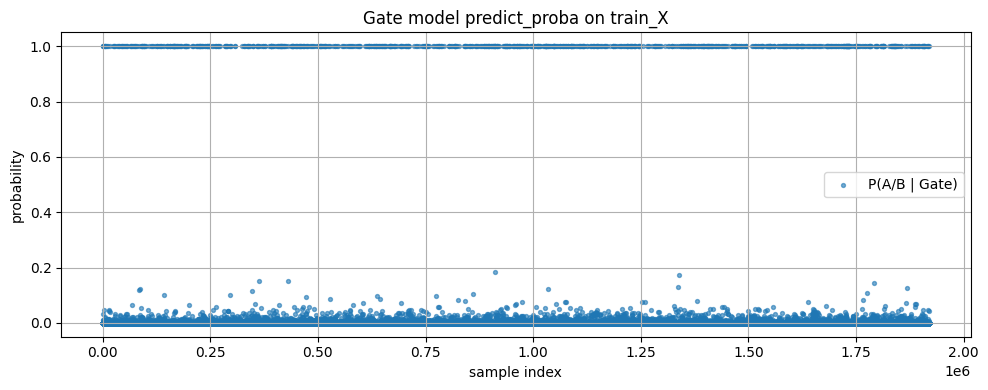

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

idx = np.arange(len(gate_proba))

plt.figure(figsize=(10,4))
plt.scatter(idx, gate_proba, s=8, alpha=0.6, label="P(A/B | Gate)")
plt.ylim(-0.05, 1.05)
plt.title("Gate model predict_proba on train_X")
plt.xlabel("sample index")
plt.ylabel("probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
